
* Student names: **Justin Mawira, Clive Kinyanjui, Brian Ireri, Faith John, Sharahbil Abdi (Group 3)**
* Pace: **full time**
* Scheduled project review date/time: 
* Instructor name: **Maryann Mwikali**
* Blog post URL:

## Business Problem
Your company has decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

## Project Summary

This analysis evaluates movie profitability using budget and revenue data from three datasets: 
- Box Office Mojo
- IMDB
- The Numbers

The results show that while blockbusters (Action, Adventure) yield the highest absolute profit, smaller budget films (esp Horror) yield greater ROI. This suggests a two-phase strategy: begin with low-budget, high-ROI genre films to build capital, then selectively invest in higher-budget franchise films to maximize long-term profitability.

In [68]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# **First dataset** ⬇️

This provides budget and revenue info

In [3]:
budget_numbers_df = pd.read_csv("../Data/tn.movie_budgets.csv.gz")
budget_numbers_df

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


## Analysis & Cleaning (tn budgets)

In [4]:
budget_numbers_df.isnull().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [5]:
budget_numbers_df.dtypes


id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object

In [6]:
budget_numbers_df_copy = budget_numbers_df.copy()

cols = ['production_budget', 'domestic_gross', 'worldwide_gross']

# remove commas and dollar signs
budget_numbers_df_copy[cols] = (
    budget_numbers_df_copy[cols]
        .replace({'\$': '', ',': ''}, regex=True)  # if the string contains metacharacters, specify regex=_ ie whether they should be treated as special characters or regular string characters
        .astype(float)   
)


In [7]:

# Net profit
budget_numbers_df_copy['net_profit'] = budget_numbers_df_copy['worldwide_gross'] - budget_numbers_df_copy['production_budget']

# ROI
budget_numbers_df_copy['ROI'] = budget_numbers_df_copy['net_profit'] / budget_numbers_df_copy['production_budget']


In [8]:
# movies that had the highest profits
budget_numbers_df_copy.sort_values('net_profit', ascending=False)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,5.532577
42,43,"Dec 19, 1997",Titanic,200000000.0,659363944.0,2.208208e+09,2.008208e+09,10.041042
6,7,"Apr 27, 2018",Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,1.748134e+09,5.827114
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09,1.747311e+09,5.710167
33,34,"Jun 12, 2015",Jurassic World,215000000.0,652270625.0,1.648855e+09,1.433855e+09,6.669092
...,...,...,...,...,...,...,...,...
352,53,"Apr 27, 2001",Town & Country,105000000.0,6712451.0,1.036477e+07,-9.463523e+07,-0.901288
341,42,"Jun 14, 2019",Men in Black: International,110000000.0,3100000.0,3.100000e+06,-1.069000e+08,-0.971818
193,94,"Mar 11, 2011",Mars Needs Moms,150000000.0,21392758.0,3.954976e+07,-1.104502e+08,-0.736335
194,95,"Dec 31, 2020",Moonfall,150000000.0,0.0,0.000000e+00,-1.500000e+08,-1.000000


In [9]:
# movies that had the highest ROI
budget_numbers_df_copy.sort_values('ROI', ascending=False)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI
5745,46,"Jun 30, 1972",Deep Throat,25000.0,45000000.0,45000000.0,44975000.0,1799.000000
5613,14,"Mar 21, 1980",Mad Max,200000.0,8750000.0,99750000.0,99550000.0,497.750000
5492,93,"Sep 25, 2009",Paranormal Activity,450000.0,107918810.0,194183034.0,193733034.0,430.517853
5679,80,"Jul 10, 2015",The Gallows,100000.0,22764410.0,41656474.0,41556474.0,415.564740
5406,7,"Jul 14, 1999",The Blair Witch Project,600000.0,140539099.0,248300000.0,247700000.0,412.833333
...,...,...,...,...,...,...,...,...
5522,23,"Dec 31, 2014",Pancakes,400000.0,0.0,0.0,-400000.0,-1.000000
5521,22,"Nov 4, 2005",Show Me,400000.0,0.0,0.0,-400000.0,-1.000000
5520,21,"Apr 1, 1986",My Beautiful Laundrette,400000.0,0.0,0.0,-400000.0,-1.000000
5116,17,"Sep 8, 2015",Checkmate,1500000.0,0.0,0.0,-1500000.0,-1.000000


Text(0, 0.5, 'Movie')

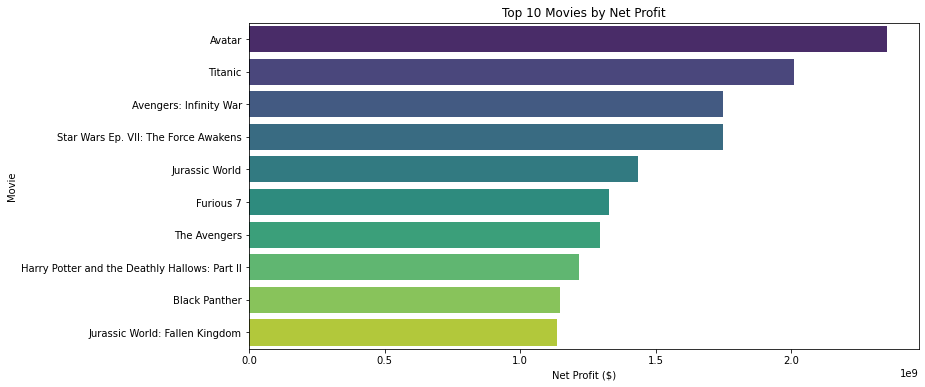

In [10]:
top10_movies = budget_numbers_df_copy.sort_values('net_profit', ascending=False).head(10)


plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_movies,
    x='net_profit',
    y='movie', 
    palette='viridis'
)

plt.title('Top 10 Movies by Net Profit')
plt.xlabel('Net Profit ($)')
plt.ylabel('Movie')

Text(0, 0.5, 'Movie')

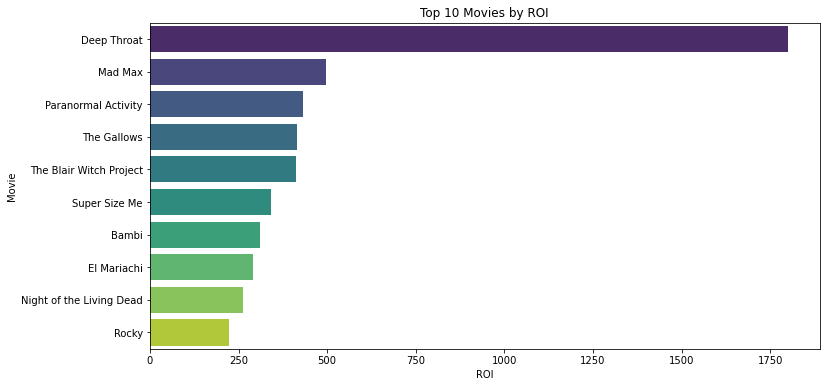

In [11]:
top10_movies_ROI = budget_numbers_df_copy.sort_values('ROI', ascending=False).head(10)


plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_movies_ROI,
    x='ROI',
    y='movie', 
    palette='viridis'
)

plt.title('Top 10 Movies by ROI')
plt.xlabel('ROI')
plt.ylabel('Movie')

### Total Gross
   - the money a movie made worldwide, ie domestic + international
### Net Profit (or Loss)
   - production budget subtracted from the total gross
### Return on Investment
   - financial ratio that measures the profitability of an investment by comparing its gain or loss relative to its cost

   - represents efficiency; a movie can have the greatest ROI but not necessarily the most profit
   
(eg. returning a profit of 1,000 from an investment of 10 vs a profit of 10,000 from an investment of 5,000)

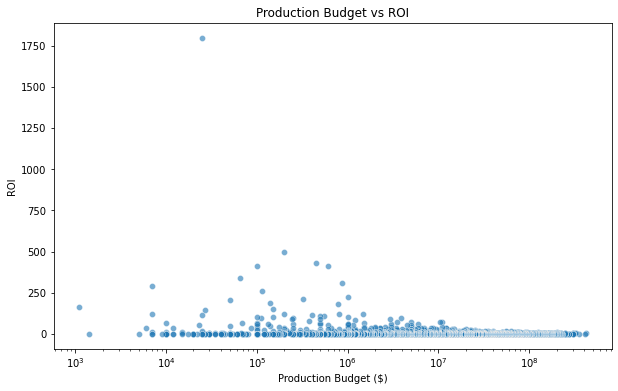

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=budget_numbers_df_copy,
    x='production_budget',
    y='ROI',
    alpha= 0.6,
)

plt.title('Production Budget vs ROI')
plt.xlabel('Production Budget ($)')
plt.ylabel('ROI')
plt.xscale('log')

In [13]:
# Convert type to datetime & extract year
budget_numbers_df_copy['release_date'] = pd.to_datetime(
    budget_numbers_df_copy['release_date'], errors='coerce'  # If a value cannot be converted to a number, make it NaN
)

budget_numbers_df_copy['release_year'] = budget_numbers_df_copy['release_date'].dt.year
budget_numbers_df_clean = budget_numbers_df_copy.dropna(subset=['release_year'])

budget_numbers_df_clean['release_year'] = budget_numbers_df_clean['release_year'].astype(int)


In [14]:
top_profit_per_year = (
    budget_numbers_df_clean.groupby('release_year')['net_profit']
    .max()
    .reset_index()
)

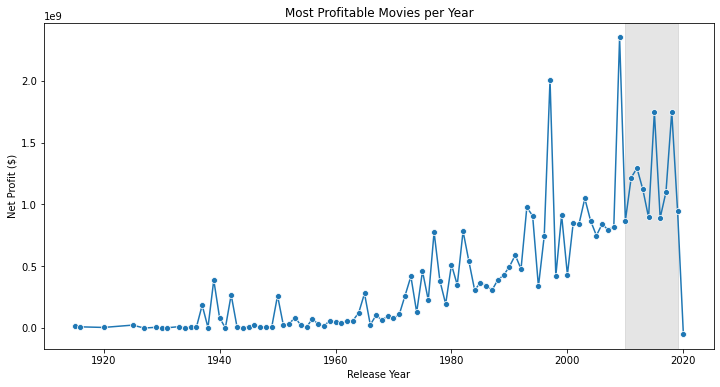

In [15]:

# line plot
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_profit_per_year,
    x='release_year',
    y='net_profit',
    marker='o'
)

plt.title('Most Profitable Movies per Year')
plt.xlabel('Release Year')
plt.ylabel('Net Profit ($)')
plt.axvspan(2010, 2019, color='gray', alpha=0.2, label='2010s')


## Insight: Profit vs ROI
Although superhero movies dominate total profit, they do not dominate ROI. 
This suggests that large studios benefit from scale, while smaller studios achieve efficiency with low-budget genre films.

* _17 movies made profits >$1,000,000,000_

* _6 of the 20 most profitable films were superhero movies_

* _17 of the 20 most profitable movies were from the 2010s_

* _ROI peaks at budgets between $100,000 and $1,000,000_

* _Movies with budgets under $1M account for 89% of films with ROI > 100_

* _Only 1 of 20 movies with the highest ROI were from the 2010s_

# **Second dataset** ⬇️

This provides review/rating info

In [16]:
# make a connection
conn = sqlite3.connect('../Data/im.db')

# create a cursor object
cur = conn.cursor()

In [17]:
pd.read_sql("""

SELECT name AS Table_Names
FROM sqlite_master
WHERE type = 'table'
            
""", conn)

,Table_Names
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [18]:
imdb_movies = pd.read_sql("""
            
SELECT *
FROM movie_basics
            
""", conn)

imdb_movies

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [19]:
imdb_ratings = pd.read_sql("""
            
SELECT *
FROM movie_ratings
            
""", conn)

imdb_ratings.sort_values('averagerating', ascending=False)

,movie_id,averagerating,numvotes
27644,tt8730716,10.0,5
8992,tt1770682,10.0,5
26153,tt2632430,10.0,5
65033,tt9715646,10.0,20
57679,tt5344358,10.0,6
...,...,...,...
50971,tt6017238,1.0,21
32440,tt2087999,1.0,7
36456,tt1896768,1.0,21
54856,tt1976600,1.0,436


In [20]:
imdb = pd.merge(
    imdb_movies,
    imdb_ratings,
    left_on=['movie_id'],
    right_on=['movie_id'],
    how='left'
)
imdb

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77.0
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43.0
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517.0
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13.0
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119.0
...,...,...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama,NaN,NaN
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary,NaN,NaN
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy,NaN,NaN
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None,NaN,NaN


In [21]:
# ratings of the most profitable movies
maxprofit_ratings = pd.read_sql("""

SELECT *
FROM movie_basics AS mb
JOIN movie_ratings AS mr
  ON mb.movie_id = mr.movie_id
WHERE (mb.primary_title = 'Beauty and the Beast' AND mb.start_year = 2017)
   OR (mb.primary_title = 'Frozen' AND mb.start_year = 2013)
   OR mb.primary_title IN (
    'The Fate of the Furious',
    'Furious 7',
    'Aquaman',
    'Iron Man 3',
    'Incredibles 2',
    'Minions',
    'Black Panther',
    'Avengers: Age of Ultron',
    'Avengers: Infinity War',
    'The Avengers',
    'Jurassic World: Fallen Kingdom',
    'Jurassic World'
)
ORDER BY mr.averagerating DESC

""", conn)

maxprofit_ratings


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,movie_id,averagerating,numvotes
0,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi",tt4154756,8.5,670926
1,tt0848228,The Avengers,The Avengers,2012,143.0,"Action,Adventure,Sci-Fi",tt0848228,8.1,1183655
2,tt3606756,Incredibles 2,Incredibles 2,2018,118.0,"Action,Adventure,Animation",tt3606756,7.7,203510
3,tt2294629,Frozen,Frozen,2013,102.0,"Adventure,Animation,Comedy",tt2294629,7.5,516998
4,tt1825683,Black Panther,Black Panther,2018,134.0,"Action,Adventure,Sci-Fi",tt1825683,7.3,516148
5,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi",tt2395427,7.3,665594
6,tt1300854,Iron Man 3,Iron Man Three,2013,130.0,"Action,Adventure,Sci-Fi",tt1300854,7.2,692794
7,tt2771200,Beauty and the Beast,Beauty and the Beast,2017,129.0,"Family,Fantasy,Musical",tt2771200,7.2,238325
8,tt2820852,Furious 7,Furious Seven,2015,137.0,"Action,Crime,Thriller",tt2820852,7.2,335074
9,tt1477834,Aquaman,Aquaman,2018,143.0,"Action,Adventure,Fantasy",tt1477834,7.1,263328


In [22]:
maxprofit_ratings['genres'].value_counts()

Action,Adventure,Sci-Fi       7
Adventure,Animation,Comedy    2
Action,Crime,Thriller         2
Action,Adventure,Animation    1
Family,Fantasy,Musical        1
Action,Adventure,Fantasy      1
Name: genres, dtype: int64

In [23]:
def clean_title(title):
    return (
        str(title)
        .lower()                # lowercase
        .replace(':', '')       # remove punctuation
        .replace('–', '-')      # standardize dashes
        .replace('!', '')
        .strip()
    )


In [24]:
# clean titles, merge dfs from datasets 1 & 2
budget_numbers_df_copy['clean_movie'] = budget_numbers_df_copy['movie'].apply(clean_title)
imdb['clean_title'] = imdb['primary_title'].apply(clean_title)

movies_merged = pd.merge(
    budget_numbers_df_copy,
    imdb,
    left_on=['clean_movie', 'release_year'],
    right_on=['clean_title', 'start_year'],
    how='left'
)

movies_merged

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,net_profit,ROI,release_year,clean_movie,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,clean_title
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2.351345e+09,5.532577,2009,avatar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,6.350639e+08,1.546673,2011,pirates of the caribbean on stranger tides,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011.0,136.0,"Action,Adventure,Fantasy",6.6,447624.0,pirates of the caribbean on stranger tides
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,-2.002376e+08,-0.572108,2019,dark phoenix,tt6565702,Dark Phoenix,Dark Phoenix,2019.0,113.0,"Action,Adventure,Sci-Fi",6.0,24451.0,dark phoenix
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,3.243841,2015,avengers age of ultron,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015.0,141.0,"Action,Adventure,Sci-Fi",7.3,665594.0,avengers age of ultron
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,9.997217e+08,3.153696,2017,star wars ep. viii the last jedi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5841,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03,-1.000000,2018,red 11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5842,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2.344950e+05,39.082500,1999,following,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5843,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03,-0.732400,2005,return to the land of wonders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5844,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03,-1.000000,2015,a plague so pleasant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
movies_merged['genres'].value_counts()

Drama                         72
Adventure,Animation,Comedy    69
Comedy                        59
Action,Adventure,Sci-Fi       54
Comedy,Drama,Romance          54
                              ..
Family,Horror,Romance          1
Biography,Drama,Mystery        1
Sci-Fi,Thriller                1
Animation,Comedy,Crime         1
Comedy,Horror,Thriller         1
Name: genres, Length: 237, dtype: int64

In [26]:
movies_merged['primary_genre'] = movies_merged['genres'].fillna('Unknown').str.split(',').str[0]

# Filter out movies where primary_genre is 'Unknown'
movies_with_genre = movies_merged[movies_merged['primary_genre'] != 'Unknown']

# Group primary genre by median profit & ROI
primary_genre_summary = (
    movies_with_genre
    .groupby('primary_genre')[['net_profit', 'ROI']]
    .median()
)



In [27]:
genre_counts = movies_with_genre['primary_genre'].value_counts()
genre_counts

Action         468
Comedy         314
Drama          283
Adventure      165
Biography      117
Horror          90
Crime           75
Documentary     46
Animation       10
Family           6
Fantasy          6
Thriller         5
Mystery          4
Romance          3
Sci-Fi           2
Music            1
Musical          1
Western          1
Name: primary_genre, dtype: int64

In [28]:
primary_genre_summary = primary_genre_summary.reset_index()
primary_genre_summary.sort_values(by='ROI', ascending=False)

,primary_genre,net_profit,ROI
13,Mystery,168268832.0,3.451364
10,Horror,29947658.5,2.886918
9,Fantasy,65228399.0,2.655138
1,Adventure,96861183.0,1.611243
4,Comedy,17159968.0,1.168138
0,Action,50972756.0,1.088923
3,Biography,16649645.0,0.869873
5,Crime,8226146.0,0.524681
7,Drama,4478084.0,0.474799
2,Animation,20325394.0,0.429613


In [29]:
roi_sorted = (
    primary_genre_summary
    .sort_values(by='ROI', ascending=False)
)

Text(0, 0.5, 'Primary Genre')

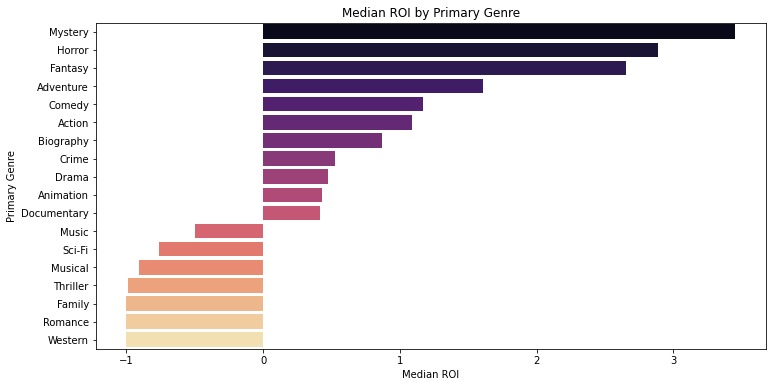

In [30]:

plt.figure(figsize=(12,6))
sns.barplot(
    data=roi_sorted,
    x='ROI',
    y='primary_genre',
    palette='magma'
)
plt.title('Median ROI by Primary Genre')
plt.xlabel('Median ROI')
plt.ylabel('Primary Genre')

In [31]:
profit_sorted = (
    primary_genre_summary
    .sort_values(by='net_profit', ascending=False)
)

Text(0, 0.5, 'Primary Genre')

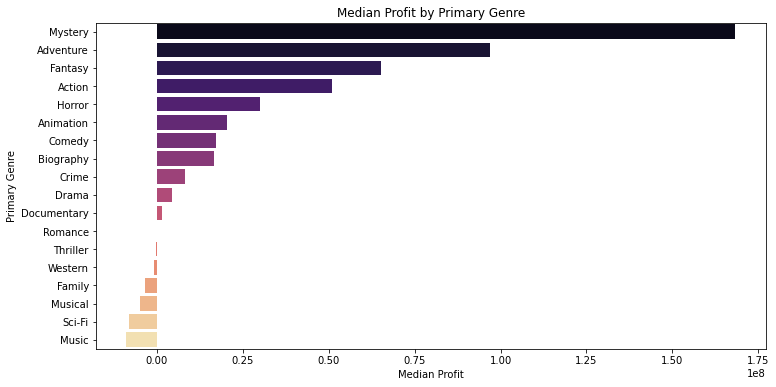

In [32]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=profit_sorted,
    x='net_profit',
    y='primary_genre',
    palette='magma'
)
plt.title('Median Profit by Primary Genre')
plt.xlabel('Median Profit')
plt.ylabel('Primary Genre')

In [33]:
mystery_count = genre_counts.loc['Mystery']
mystery_pct = mystery_count / genre_counts.sum()

mystery_count, mystery_pct

(4, 0.002504696305572949)

In [34]:
horror_count = genre_counts.loc['Horror']
horror_pct = horror_count / genre_counts.sum()

horror_count, horror_pct

(90, 0.056355666875391355)

In [35]:
adventure_count = genre_counts.loc['Adventure']
adventure_pct = adventure_count / genre_counts.sum()

adventure_count, adventure_pct

(165, 0.10331872260488416)

In [36]:
fantasy_count = genre_counts.loc['Fantasy']
fantasy_pct = fantasy_count / genre_counts.sum()

fantasy_count, fantasy_pct

(6, 0.003757044458359424)

In [37]:
action_count = genre_counts.loc['Action']
action_pct = action_count / genre_counts.sum()

action_count, action_pct

(468, 0.29304946775203505)

Using the first listed genre as 'primary genre' provides a consistent (though imperfect) proxy for a movie’s primary marketing category and reduces the messiness of having to deal w >200 genres

Using median values to reduce the influence of extreme outliers common in movie revenue data

In [38]:

profit_ratings = movies_merged[movies_merged['numvotes'] >= 1000]


(-500000000.0, 2000000000.0)

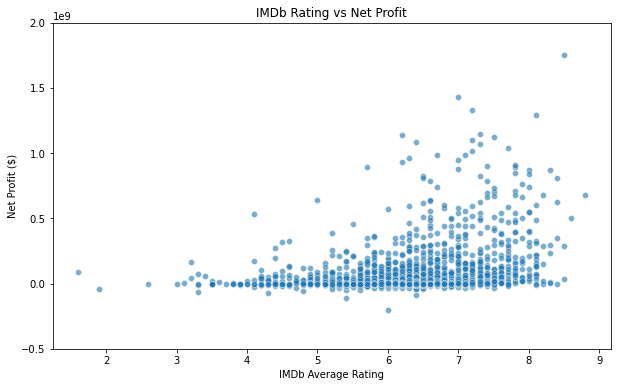

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=profit_ratings,
    x='averagerating',
    y='net_profit',
    alpha=0.6
)

plt.title('IMDb Rating vs Net Profit')
plt.xlabel('IMDb Average Rating')
plt.ylabel('Net Profit ($)')
plt.ylim(-0.5e9, 2e9)



## Insight: Genre & Ratings
Critical acclaim is not a prerequisite for box office success. A highly rated film can underperform financially. However successful movies do tend to cluster around ratings between 6.5 and 8.5. The Horror genre did particularly well in terms of ROI, while Action / Adventure faired better in terms of net profit.

* _7 of 14 movies with the highest net profit were of the primary genre, 'Action'_

* _Of the 14, the average rating ranges from 8.5 - 6.2 for Avengers: Infinity War & Jurassic World: Fallen Kingdom respectively_

* _>3600 movies were rated higher than Infinity War, and >40000 movies were rated higher than Fallen Kingdom_

* _The primary genres, 'Mystery' & 'Horror' have the highest median ROI (the mystery sample size is however too small - 4)_

* _'Adventure', 'Mystery', 'Fantasy', 'Action' have the highest median Profit (the fantasy sample size is too small - 6)_

# **Third dataset** ⬇️

This provides box office figures

In [40]:
boxoffice_df = pd.read_csv("../Data/bom.movie_gross.csv.gz")
boxoffice_df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


## Analysis & cleaning (bom gross)

In [41]:
boxoffice_df.isnull().sum()


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [42]:
boxoffice_df.dtypes


title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [43]:
boxoffice_df['foreign_gross'].map(type).value_counts()


<class 'str'>      2037
<class 'float'>    1350
Name: foreign_gross, dtype: int64

In [44]:
boxoffice_df['foreign_gross'].str.contains(',', na=False).any()



True

In [45]:
boxoffice_df_copy = boxoffice_df.copy()

# Convert strings
boxoffice_df_copy['foreign_gross'] = pd.to_numeric(
    boxoffice_df['foreign_gross'].astype(str).str.replace(',', ''),
    errors='coerce'
)


In [46]:
# total gross
boxoffice_df_copy['total_gross'] = boxoffice_df_copy['domestic_gross'] + boxoffice_df_copy['foreign_gross']

boxoffice_df_copy.sort_values('total_gross', ascending=False)

,title,studio,domestic_gross,foreign_gross,year,total_gross
727,Marvel's The Avengers,BV,623400000.0,895500000.0,2012,1.518900e+09
1875,Avengers: Age of Ultron,BV,459000000.0,946400000.0,2015,1.405400e+09
3080,Black Panther,BV,700100000.0,646900000.0,2018,1.347000e+09
328,Harry Potter and the Deathly Hallows Part 2,WB,381000000.0,960500000.0,2011,1.341500e+09
2758,Star Wars: The Last Jedi,BV,620200000.0,712400000.0,2017,1.332600e+09
...,...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018,NaN
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018,NaN
3384,El Pacto,Sony,2500.0,NaN,2018,NaN
3385,The Swan,Synergetic,2400.0,NaN,2018,NaN


In [60]:
# cleaning titles and merging dfs
boxoffice_df_copy['clean_title'] = boxoffice_df_copy['title'].apply(clean_title)

movie_studios = pd.merge(
    movies_merged,
    boxoffice_df_copy,
    left_on=['clean_movie', 'release_year'],
    right_on=['clean_title', 'year'],
    how='left'
)
movie_studios.sort_values('total_gross', ascending=False) # all 3 datasets merged

,id,release_date,movie,production_budget,domestic_gross_x,worldwide_gross,net_profit,ROI,release_year,clean_movie,...,numvotes,clean_title_x,primary_genre,title,studio,domestic_gross_y,foreign_gross,year,total_gross,clean_title_y
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,1.072414e+09,3.243841,2015,avengers age of ultron,...,665594.0,avengers age of ultron,Action,Avengers: Age of Ultron,BV,459000000.0,946400000.0,2015.0,1.405400e+09,avengers age of ultron
41,42,2018-02-16,Black Panther,200000000.0,700059566.0,1.348258e+09,1.148258e+09,5.741291,2018,black panther,...,516148.0,black panther,Action,Black Panther,BV,700100000.0,646900000.0,2018.0,1.347000e+09,black panther
114,13,2018-06-22,Jurassic World: Fallen Kingdom,170000000.0,417719760.0,1.305773e+09,1.135773e+09,6.681016,2018,jurassic world fallen kingdom,...,219125.0,jurassic world fallen kingdom,Action,Jurassic World: Fallen Kingdom,Uni.,417700000.0,891800000.0,2018.0,1.309500e+09,jurassic world fallen kingdom
157,56,2013-11-22,Frozen,150000000.0,400738009.0,1.272470e+09,1.122470e+09,7.483133,2013,frozen,...,516998.0,frozen,Adventure,Frozen,BV,400700000.0,875700000.0,2013.0,1.276400e+09,frozen
43,44,2018-06-15,Incredibles 2,200000000.0,608581744.0,1.242521e+09,1.042521e+09,5.212604,2018,incredibles 2,...,203510.0,incredibles 2,Action,Incredibles 2,BV,608600000.0,634200000.0,2018.0,1.242800e+09,incredibles 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5841,78,2018-12-31,Red 11,7000.0,0.0,0.000000e+00,-7.000000e+03,-1.000000,2018,red 11,...,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5842,79,1999-04-02,Following,6000.0,48482.0,2.404950e+05,2.344950e+05,39.082500,1999,following,...,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5843,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1.338000e+03,-3.662000e+03,-0.732400,2005,return to the land of wonders,...,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5844,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.000000e+00,-1.400000e+03,-1.000000,2015,a plague so pleasant,...,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
'The Avengers' in movie_studios['movie'].values


True

In [67]:
"Marvel's The Avengers" in movie_studios['movie'].values


False

_The **left join** erased Marvel's The Avengers since it was titled differently on movies_merged_

In [61]:
studio_gross = (
    boxoffice_df_copy
    .groupby('studio')['total_gross']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_studios = studio_gross.head(10)


Text(0, 0.5, 'Studio')

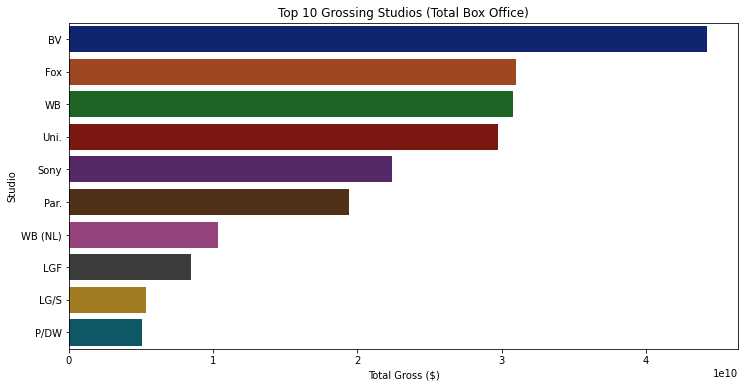

In [62]:

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_studios,
    x='total_gross',
    y='studio',
    palette='dark'
)

plt.title('Top 10 Grossing Studios (Total Box Office)')
plt.xlabel('Total Gross ($)')
plt.ylabel('Studio')


In [63]:
# studios with the highest production budgets

ballers = movie_studios.sort_values('production_budget', ascending=False)

top_budget_studios = (
    movie_studios
    .dropna(subset=['studio'])              # remove movies without studio info
    .groupby('studio')['production_budget']
    .sum()                                  # total budget per studio
    .sort_values(ascending=False)
    .head(10)
)

top_budget_studios


studio
BV         1.025080e+10
WB         8.784000e+09
Fox        7.881000e+09
Uni.       6.911200e+09
Sony       5.150500e+09
Par.       4.782000e+09
WB (NL)    2.240600e+09
LGF        2.209388e+09
LG/S       1.741500e+09
P/DW       1.334000e+09
Name: production_budget, dtype: float64

In [51]:
top_budget_studios = top_budget_studios.reset_index()


Text(0.5, 1.0, 'Top 10 Studios by Total Production Budget')

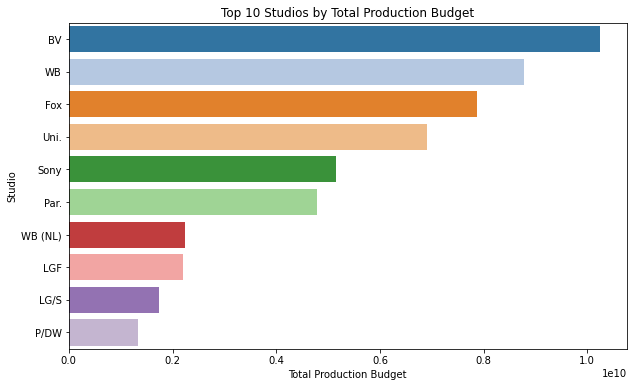

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_budget_studios,
    x='production_budget',
    y='studio',
    palette='tab20'
)
# top_budget_studios.sort_values().plot(kind='barh')
plt.xlabel('Total Production Budget')
plt.ylabel('Studio')
plt.title('Top 10 Studios by Total Production Budget')


In [53]:
# studios with the highest net profit

ballers_p = movie_studios.sort_values('net_profit', ascending=False)

top_profit_studios = (
    movie_studios
    .dropna(subset=['studio'])              # remove movies without studio info
    .groupby('studio')['net_profit']
    .sum()                                  # total budget per studio
    .sort_values(ascending=False)
    .head(10)
)

top_profit_studios

studio
BV         2.539413e+10
Uni.       2.121927e+10
Fox        1.939115e+10
WB         1.547573e+10
Sony       1.257329e+10
Par.       9.622779e+09
WB (NL)    6.699504e+09
LGF        4.975932e+09
P/DW       3.744028e+09
LG/S       2.215932e+09
Name: net_profit, dtype: float64

In [54]:
top_profit_studios = top_profit_studios.reset_index()

Text(0.5, 1.0, 'Top 10 Studios by Net Profit')

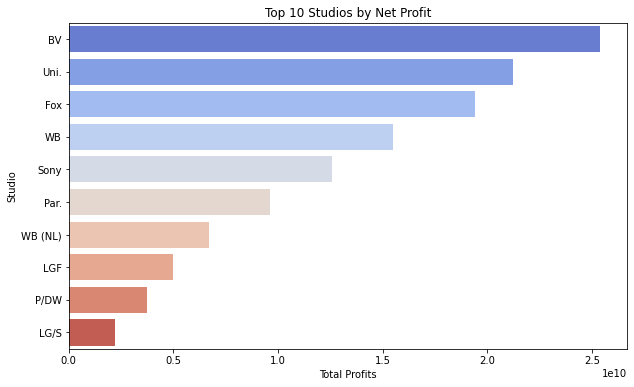

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_profit_studios,
    x='net_profit',
    y='studio',
    palette='coolwarm'
)
# top_profit_studios.sort_values().plot(kind='barh')
plt.xlabel('Total Profits')
plt.ylabel('Studio')
plt.title('Top 10 Studios by Net Profit')

## Insight: Box Office

Superhero movies led at the box office (gross). BV led the studios in terms of production budget & net profit.

* _The top 3 highest-grossing films are all superhero movies - all by Buena Vista_

* _7 of the top 20 are superhero movies_

* _12 of the top 20 films are from the same studio - BV_

* _Buena Vista (Disney) dominates box office revenue, reflecting the advantage of established franchises_


In [ ]:
movie_studios.to_csv("imdb_budget_studios.csv", index=False)

## Business Recommendations

1. Start by investing in low-budget genre films ('Horror') to maximize ROI and reduce downside risk

2. Later on, explore investments in mid-to-high budget franchise films, ('Action'/'Adventure' genres or tapping into big existing IP like Harry Potter) to maximize net profit

3. In terms of marketing: for low-budget genre films, focus on cost-efficient marketing like social media campaigns. while for high-budget franchise films, invest heavily in pre-release hype and cross-promotion (like videogame or toy partnerships) to maximize returns

4. We also recommend partnering with an established studio such as Buena Vista on a high-budget project (for example, an action film) to leverage their experience and resources, including substantial production funding and robust marketing capabilities

## Data Limitations

- Matching movie titles across datasets may introduce errors
- ROI & Profit are calculated using production budget only, as marketing costs are not available in the dataset